In [1]:
import pandas as pd
import numpy as np
import tkinter as tk
import matplotlib.pyplot as plt
import umap

from pathlib import Path
from tkinter import filedialog
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import Isomap, MDS, TSNE

In [2]:
def load_dataframe_from_path(path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"No existe el archivo: {path}")

    ext = path.suffix.lower()

    if ext == ".csv":
        df = pd.read_csv(path, delimiter=",")
        
    elif ext in [".otus", ".txt", ".meta", ".taxonomy"]:
        df = pd.read_csv(path, sep="\t")
        
    else:
        raise ValueError(
            f"Formato no soportado: {ext}. "
            "Usa archivos .csv, .otus, .txt, .meta o .taxonomy"
        )

    return df


def load_multiple_dataframes():
    root = tk.Tk()
    root.withdraw()  
    root.attributes("-topmost", True)  

    file_paths = filedialog.askopenfilenames(
        title="Selecciona uno o varios datasets",
        filetypes=[
            ("Archivos soportados", "*.csv *.otus *.txt *.meta *.taxonomy"),
            ("CSV", "*.csv"),
            ("OTUS", "*.otus"),
            ("TXT", "*.txt"),
            ("META", "*.meta"),
            ("TAXONOMY", "*.taxonomy"),
            ("Todos los archivos", "*.*")
        ]
    )

    if not file_paths:
        print("No se seleccionó ningún archivo.")
        return {}

    dataframes = {}

    for file_path in file_paths:
        path = Path(file_path)
        try:
            df = load_dataframe_from_path(path)
            dataframes[path.stem] = df
            print(f"Cargado: {path.name} -> shape {df.shape}")
        except Exception as e:
            print(f"Error al cargar {path.name}: {e}")

    return dataframes

In [3]:
dfs = load_multiple_dataframes()

if not dfs:
    print("No se cargó ningún archivo.")
else:
    for nombre, df in dfs.items():
        print(f"\nArchivo cargado: {nombre}")
        print(f"Shape del DataFrame: {df.shape}")
        print(f"Columnas: {df.columns.tolist()[:10]}{' ...' if len(df.columns) > 10 else ''}")

Cargado: anthro_data.meta -> shape (441, 33)
Cargado: otu_data_converted.csv -> shape (441, 4739)

Archivo cargado: anthro_data
Shape del DataFrame: (441, 33)
Columnas: ['ID', 'city', 'socioeconomic', 'sex', 'age', 'age_range', 'HDL', 'LDL', 'cholesterol', 'triglycerides'] ...

Archivo cargado: otu_data_converted
Shape del DataFrame: (441, 4739)
Columnas: ['ID', 'Otu00001', 'Otu00002', 'Otu00003', 'Otu00004', 'Otu00005', 'Otu00006', 'Otu00007', 'Otu00008', 'Otu00009'] ...


In [5]:
print(list(dfs.keys()))
#otu_df = dfs["otu_data_converted"]
anthro_df = dfs["anthro_data"]
#otu_df.head()
anthro_df.head()

['anthro_data', 'otu_data_converted']


,ID,city,socioeconomic,sex,age,age_range,HDL,LDL,cholesterol,triglycerides,...,waist,medicament,fiber,per_protein,per_animal_protein,per_total_fat,per_saturated_fat,per_monoinsaturated_fat,per_polyunsaturated_fat,per_carbohydrates
0,MI_001_H,Medellin,3,Male,36,18_40,38,93.0,170,195,...,97.6,No,19,16.15,60.53,28.40,11.01,9.88,4.82,55.47
1,MI_002_H,Medellin,2,Female,40,18_40,52,130.0,202,100,...,89.3,No,13,13.77,66.88,29.74,11.61,10.35,6.55,56.10
2,MI_003_H,Medellin,3,Male,53,41_62,51,119.0,185,76,...,92.8,No,13,14.57,64.75,24.20,9.48,8.10,4.84,61.37
3,MI_004_H,Medellin,5,Male,58,41_62,59,120.0,199,99,...,84.7,Yes,16,19.17,65.78,28.72,11.60,10.63,5.03,51.28
4,MI_005_H,Medellin,3,Female,44,41_62,73,63.0,159,114,...,73.3,Yes,21,13.86,59.40,28.40,9.91,9.66,6.92,57.50


In [6]:
def get_df_from_dfs(dfs, df_name):
    if df_name not in dfs:
        raise KeyError(f"No existe '{df_name}' en dfs. Disponibles: {list(dfs.keys())}")
    return dfs[df_name].copy()


def clr_transform(X, pseudocount=1.0):

    X = np.asarray(X, dtype=float)

    if np.any(X < 0):
        raise ValueError("La matriz contiene valores negativos; CLR no es apropiada así.")

    X_pc = X + pseudocount
    row_sums = X_pc.sum(axis=1, keepdims=True)

    if np.any(row_sums == 0):
        raise ValueError("Hay filas con suma 0 incluso tras pseudocount.")

    X_closed = X_pc / row_sums
    log_X = np.log(X_closed)
    gm_log = log_X.mean(axis=1, keepdims=True)
    X_clr = log_X - gm_log

    return X_clr


def apply_feature_transform(X, method="none", pseudocount=1.0):

    method = method.lower()

    if method == "none":
        return X

    if method == "log1p":
        if np.any(X < 0):
            raise ValueError("log1p no admite valores negativos.")
        return np.log1p(X)

    if method == "clr":
        return clr_transform(X, pseudocount=pseudocount)

    raise ValueError(f"Transformación no soportada: {method}")


def apply_embedding(X_scaled, method="pca", n_components=10, random_state=42, **kwargs):

    method = method.lower()

    if method == "none":
        return X_scaled, None

    if method == "pca":
        max_components = min(n_components, X_scaled.shape[0] - 1, X_scaled.shape[1])
        if max_components < 2:
            raise ValueError("No hay suficientes dimensiones para PCA.")
        model = PCA(n_components=max_components, random_state=random_state)
        X_embed = model.fit_transform(X_scaled)
        return X_embed, model

    if method == "kpca":
        max_components = min(n_components, X_scaled.shape[0] - 1, X_scaled.shape[1])
        if max_components < 2:
            raise ValueError("No hay suficientes dimensiones para KernelPCA.")
        model = KernelPCA(
            n_components=max_components,
            kernel=kwargs.get("kernel", "rbf"),
            gamma=kwargs.get("gamma", None)
        )
        X_embed = model.fit_transform(X_scaled)
        return X_embed, model

    if method == "isomap":
        max_components = min(n_components, X_scaled.shape[0] - 1, X_scaled.shape[1])
        if max_components < 2:
            raise ValueError("No hay suficientes dimensiones para Isomap.")
        model = Isomap(
            n_components=max_components,
            n_neighbors=kwargs.get("n_neighbors", 10)
        )
        X_embed = model.fit_transform(X_scaled)
        return X_embed, model

    if method == "mds":
        max_components = min(n_components, X_scaled.shape[0] - 1)
        if max_components < 2:
            raise ValueError("No hay suficientes dimensiones para MDS.")
        model = MDS(
            n_components=max_components,
            random_state=random_state,
            n_init=kwargs.get("n_init", 4),
            max_iter=kwargs.get("max_iter", 300)
        )
        X_embed = model.fit_transform(X_scaled)
        return X_embed, model

    if method == "tsne":
        max_components = min(n_components, 3)
        if max_components < 2:
            raise ValueError("t-SNE requiere al menos 2 componentes.")
        model = TSNE(
            n_components=max_components,
            random_state=random_state,
            perplexity=kwargs.get("perplexity", 30),
            init=kwargs.get("init", "pca"),
            learning_rate=kwargs.get("learning_rate", "auto")
        )
        X_embed = model.fit_transform(X_scaled)
        return X_embed, model

    if method == "umap":
        if not HAS_UMAP:
            raise ImportError("UMAP no está instalado. Usa: pip install umap-learn")
        max_components = min(n_components, X_scaled.shape[1])
        if max_components < 2:
            raise ValueError("UMAP requiere al menos 2 componentes.")
        model = umap.UMAP(
            n_components=max_components,
            n_neighbors=kwargs.get("n_neighbors", 15),
            min_dist=kwargs.get("min_dist", 0.1),
            metric=kwargs.get("metric", "euclidean"),
            random_state=random_state
        )
        X_embed = model.fit_transform(X_scaled)
        return X_embed, model

    raise ValueError(f"Embedding no soportado: {method}")


def prepare_data_for_dbscan(
    df,
    id_col=None,
    feature_cols=None,
    drop_non_numeric=True,
    missing_strategy="fill_zero",
    remove_zero_rows=False,
    min_prevalence=None,
    min_total_abundance=None,
    transform_method="none",
    pseudocount=1.0,
    scale=True,
    embedding_method="pca",
    n_components=10,
    random_state=42,
    embedding_kwargs=None,
    verbose=True
):

    work_df = df.copy()

    if id_col is not None and id_col not in work_df.columns:
        raise KeyError(f"La columna ID '{id_col}' no existe en el DataFrame")

    if feature_cols is None:
        feature_cols = [c for c in work_df.columns if c != id_col]
    else:
        faltantes = [c for c in feature_cols if c not in work_df.columns]
        if faltantes:
            raise KeyError(f"Estas columnas no existen en el DataFrame: {faltantes}")

    ids = None
    if id_col is not None:
        ids = work_df[id_col].astype(str).str.strip().reset_index(drop=True)

    X_df = work_df[feature_cols].copy()

    for col in X_df.columns:
        X_df[col] = pd.to_numeric(X_df[col], errors="coerce")

    if drop_non_numeric:
        X_df = X_df.select_dtypes(include=[np.number])

    if X_df.shape[1] == 0:
        raise ValueError("No quedaron columnas numéricas para clustering.")

    if missing_strategy == "fill_zero":
        X_df = X_df.fillna(0)
    elif missing_strategy == "drop_rows":
        valid_mask = X_df.notna().all(axis=1)
        X_df = X_df.loc[valid_mask].reset_index(drop=True)
        if ids is not None:
            ids = ids.loc[valid_mask].reset_index(drop=True)
    else:
        raise ValueError("missing_strategy debe ser 'fill_zero' o 'drop_rows'.")

    if remove_zero_rows:
        row_sums = X_df.sum(axis=1)
        valid_rows = row_sums > 0
        X_df = X_df.loc[valid_rows].reset_index(drop=True)
        if ids is not None:
            ids = ids.loc[valid_rows].reset_index(drop=True)

    if X_df.shape[0] == 0:
        raise ValueError("No quedaron filas válidas para clustering.")

    if min_prevalence is not None:
        prevalence = (X_df > 0).mean(axis=0)
        X_df = X_df.loc[:, prevalence >= min_prevalence]

    if min_total_abundance is not None:
        total_abundance = X_df.sum(axis=0)
        X_df = X_df.loc[:, total_abundance >= min_total_abundance]

    if X_df.shape[1] == 0:
        raise ValueError("No quedaron columnas tras los filtros aplicados.")

    X_raw = X_df.values.astype(float)

    X_transformed = apply_feature_transform(
        X_raw,
        method=transform_method,
        pseudocount=pseudocount
    )

    if scale:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_transformed)
    else:
        scaler = None
        X_scaled = X_transformed

    if embedding_kwargs is None:
        embedding_kwargs = {}

    X_embed, embedding_model = apply_embedding(
        X_scaled=X_scaled,
        method=embedding_method,
        n_components=n_components,
        random_state=random_state,
        **embedding_kwargs
    )

    if ids is None:
        ids = pd.Series(np.arange(len(X_embed)).astype(str), name="row_id")

    if verbose:
        print("=== Preparación general para DBSCAN ===")
        print(f"Filas válidas: {X_df.shape[0]}")
        print(f"Variables retenidas: {X_df.shape[1]}")
        print(f"Transformación: {transform_method}")
        print(f"Escalado: {scale}")
        print(f"Embedding: {embedding_method}")
        print(f"Dimensiones embedding: {X_embed.shape[1]}")

        if embedding_method == "pca" and hasattr(embedding_model, "explained_variance_ratio_"):
            explained_var = embedding_model.explained_variance_ratio_
            print(f"Varianza explicada acumulada PCA: {explained_var.cumsum()[-1]:.4f}")

    prepared = {
        "ids": ids.reset_index(drop=True),
        "feature_names": X_df.columns.tolist(),
        "X_raw": X_raw,
        "X_transformed": X_transformed,
        "X_scaled": X_scaled,
        "X_embed": X_embed,
        "transform_method": transform_method,
        "scale": scale,
        "embedding_method": embedding_method,
        "embedding_model": embedding_model,
        "filtered_df": pd.concat([ids.reset_index(drop=True), X_df.reset_index(drop=True)], axis=1)
    }

    if embedding_method == "pca" and hasattr(embedding_model, "explained_variance_ratio_"):
        prepared["explained_variance_ratio"] = embedding_model.explained_variance_ratio_

    return prepared


def plot_k_distance(X, min_samples=8, figsize=(8, 5)):
    if min_samples < 2:
        raise ValueError("min_samples debe ser al menos 2.")

    nn = NearestNeighbors(n_neighbors=min_samples)
    nn.fit(X)
    distances, _ = nn.kneighbors(X)

    k_distances = np.sort(distances[:, -1])

    plt.figure(figsize=figsize)
    plt.plot(k_distances)
    plt.xlabel("Muestras ordenadas")
    plt.ylabel(f"Distancia al vecino #{min_samples}")
    plt.title("K-distance plot para elegir eps")
    plt.grid(True, alpha=0.3)
    plt.show()

    return k_distances


def run_dbscan(
    prepared,
    eps,
    min_samples=8,
    id_col="ID",
    meta_df=None,
    meta_id_col="ID",
    verbose=True
):
    X = prepared["X_embed"]
    ids = prepared["ids"].reset_index(drop=True).astype(str)

    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X)

    result_df = pd.DataFrame({
        id_col: ids,
        "dbscan_cluster": labels
    })

    result_df["dbscan_is_noise"] = result_df["dbscan_cluster"] == -1

    if meta_df is not None:
        meta = meta_df.copy()
        if meta_id_col not in meta.columns:
            raise KeyError(f"La columna '{meta_id_col}' no existe en meta_df")

        meta[meta_id_col] = meta[meta_id_col].astype(str).str.strip()
        result_df[id_col] = result_df[id_col].astype(str).str.strip()

        merged = pd.merge(
            result_df,
            meta,
            left_on=id_col,
            right_on=meta_id_col,
            how="left"
        )

        if meta_id_col != id_col and meta_id_col in merged.columns:
            merged = merged.drop(columns=[meta_id_col])

        result_df = merged

    if verbose:
        counts = pd.Series(labels).value_counts().sort_index()
        print("=== Resultado DBSCAN ===")
        print(counts)
        n_noise = int((labels == -1).sum())
        print(f"Ruido (-1): {n_noise}")
        print(f"Clusters reales: {len(set(labels)) - (1 if -1 in labels else 0)}")

    return result_df, model


def plot_dbscan_embedding(
    prepared,
    cluster_df,
    id_col="ID",
    label_col="dbscan_cluster",
    figsize=(8, 6)
):
    X_embed = prepared["X_embed"]
    method = prepared.get("embedding_method", "embedding")

    if X_embed.shape[1] < 2:
        raise ValueError("Se necesitan al menos 2 dimensiones para graficar.")

    plot_df = pd.DataFrame(X_embed[:, :2], columns=["Dim1", "Dim2"])
    plot_df[id_col] = prepared["ids"].astype(str).values

    aux = cluster_df[[id_col, label_col]].copy()
    aux[id_col] = aux[id_col].astype(str).str.strip()
    plot_df[id_col] = plot_df[id_col].astype(str).str.strip()

    plot_df = plot_df.merge(aux, on=id_col, how="left")

    plt.figure(figsize=figsize)

    for cluster_id in sorted(plot_df[label_col].dropna().unique()):
        subset = plot_df[plot_df[label_col] == cluster_id]
        label = "Ruido" if cluster_id == -1 else f"Cluster {cluster_id}"
        plt.scatter(subset["Dim1"], subset["Dim2"], label=label, alpha=0.7)

    plt.xlabel("Dim1")
    plt.ylabel("Dim2")
    plt.title(f"DBSCAN sobre {method.upper()}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [7]:
otu_df = get_df_from_dfs(dfs, "otu_data_converted")
meta_df = get_df_from_dfs(dfs, "anthro_data")


In [31]:
prepared = prepare_data_for_dbscan(
    df=meta_df,
    id_col="ID",
    feature_cols=["waist","age","HDL"],
    remove_zero_rows=True,
    min_prevalence=None,
    transform_method="none",
    scale=True,
    embedding_method="pca",
    n_components=3,
    verbose=True
)

=== Preparación general para DBSCAN ===
Filas válidas: 441
Variables retenidas: 3
Transformación: none
Escalado: True
Embedding: pca
Dimensiones embedding: 3
Varianza explicada acumulada PCA: 1.0000


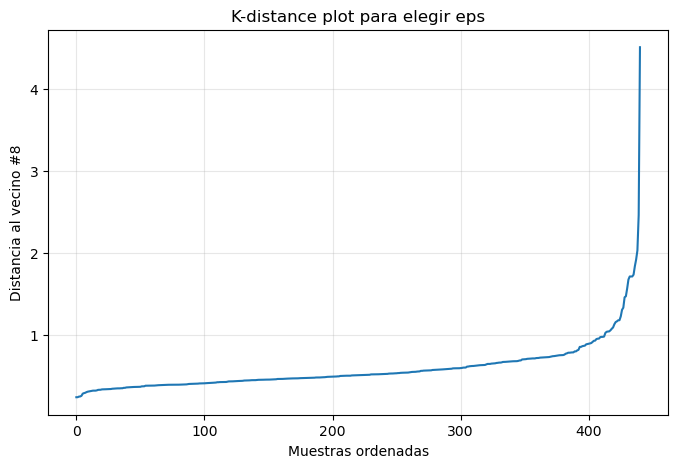

In [32]:
k_distances = plot_k_distance(
    X=prepared["X_embed"],
    min_samples=8
)

In [34]:
dbscan_result, dbscan_model = run_dbscan(
    prepared=prepared,
    eps=1,
    min_samples=3,
    id_col="ID",
    meta_df=meta_df,
    meta_id_col="ID",
    verbose=True
)

=== Resultado DBSCAN ===
-1      9
 0    429
 1      3
Name: count, dtype: int64
Ruido (-1): 9
Clusters reales: 2


In [35]:
dbscan_result.head()

,ID,dbscan_cluster,dbscan_is_noise,city,socioeconomic,sex,age,age_range,HDL,LDL,...,waist,medicament,fiber,per_protein,per_animal_protein,per_total_fat,per_saturated_fat,per_monoinsaturated_fat,per_polyunsaturated_fat,per_carbohydrates
0,MI_001_H,0,False,Medellin,3,Male,36,18_40,38,93.0,...,97.6,No,19,16.15,60.53,28.40,11.01,9.88,4.82,55.47
1,MI_002_H,0,False,Medellin,2,Female,40,18_40,52,130.0,...,89.3,No,13,13.77,66.88,29.74,11.61,10.35,6.55,56.10
2,MI_003_H,0,False,Medellin,3,Male,53,41_62,51,119.0,...,92.8,No,13,14.57,64.75,24.20,9.48,8.10,4.84,61.37
3,MI_004_H,0,False,Medellin,5,Male,58,41_62,59,120.0,...,84.7,Yes,16,19.17,65.78,28.72,11.60,10.63,5.03,51.28
4,MI_005_H,0,False,Medellin,3,Female,44,41_62,73,63.0,...,73.3,Yes,21,13.86,59.40,28.40,9.91,9.66,6.92,57.50


In [36]:
dbscan_result["dbscan_cluster"].value_counts().sort_index()

dbscan_cluster
-1      9
 0    429
 1      3
Name: count, dtype: int64

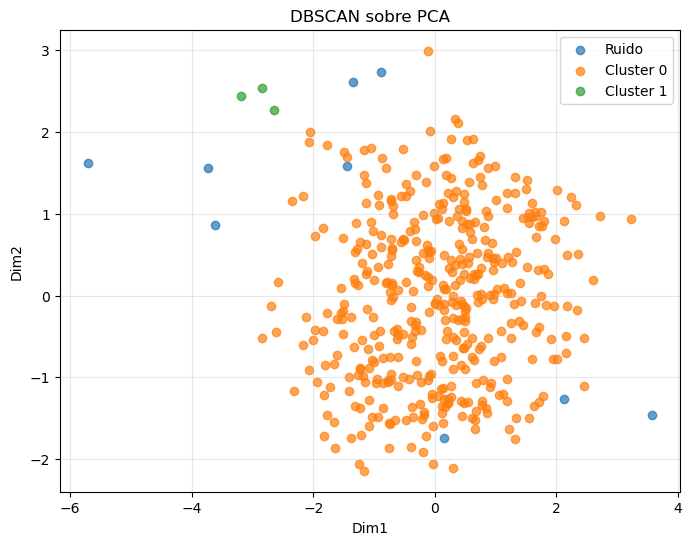

In [37]:
plot_dbscan_embedding(prepared, dbscan_result)

In [38]:
dbscan_result.groupby("dbscan_cluster")["glucose"].median()
dbscan_result.groupby("dbscan_cluster")["waist"].median()
dbscan_result.groupby("dbscan_cluster")["bmi_class"].value_counts()

dbscan_cluster  bmi_class 
-1              Lean            4
                Obese           4
                Overweight      1
 0              Overweight    169
                Lean          132
                Obese         128
 1              Lean            2
                Overweight      1
Name: count, dtype: int64